# 待解決問題
1. 某個record會預測出對應sample_time的target data，但這個target data並不是因為單一record所導致的，而是因為一段record造成的

# 描述性統計
## 變異性
1. 總體變異程度
2. sample slot內的變異程度

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [6]:
result: dict[str, pd.DataFrame] = {}

for file in os.listdir("./processed_data"):
    if file.endswith(".csv"):
        df:pd.DataFrame = pd.read_csv(f"./processed_data/{file}")
        df['sample_time'] = pd.to_datetime(df['sample_time'])
        result[f'{file.replace(".csv", "")}'] = df

result_keys = list(result.keys())

sample_times = result[result_keys[0]]['sample_time'].unique()

/tmp/ipykernel_4664/2926703907.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df:pd.DataFrame = pd.read_csv(f"./processed_data/{file}")


In [ ]:
# KDA和時間序列圖
for col in result["API"].columns:
    if col not in ['TimeStamp', "Batch", "sample_time", "sample_id"]:
        plt.figure(figsize=(20, 5))
        
        # 如果是二元值
        if result['API'][col].unique().shape[0] == 2:
            plt.scatter(result['API']['TimeStamp'], result['API'][col], alpha=0.5)  # 繪製散點圖
            plt.yticks([0, 1])  # 限制 Y 軸為 0 和 1
        else:
            plt.plot(result['API']["TimeStamp"], result['API'][col])
        
        for sample_time in sample_times:
            plt.axvline(sample_time, color='r', linestyle='--')

        plt.title(col)
        plt.xlabel('Value', fontsize=16)
        plt.show()

# 數據分析

## 策略
1. 先將資料依照sample_time分組
2. 先用F檢定來找出顯著變數，再來使用機器學習方法來做預測
3. 使用PCA作為比較基礎

## 機器學習方法
1. 隨機森林回歸
2. XGboot

In [7]:
from cuml.model_selection import train_test_split
from cuml.ensemble import RandomForestRegressor
from cuml.metrics import mean_squared_error, r2_score
from cuml.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

In [18]:
class PCAProcessor:
    def __init__(self, name: str, model_path: str = '/model',n_components=None):
        """
        PCAProcessor 類別，用於處理數據降維
        :param n_components: 主成分數，None 表示自動選擇可解釋 95% 變異數的成分數
        """
        self.n_components = n_components
        self.pca = None  # 初始化 PCA 物件
        self.model_path = model_path # 儲存模型路徑
        self.name = name # 儲存模型名稱

    def fit_transform(self, X: np.ndarray, save_model=True) -> np.ndarray:
        """
        擬合並轉換數據，並可選擇是否儲存 PCA 模型
        :param X: 原始數據 (np.ndarray)
        :param save_model: 是否儲存 PCA 模型，預設為 True
        :return: 降維後的數據
        """
        from sklearn.decomposition import PCA  # 避免 cuML 環境問題

        if self.n_components is None:
            self.pca = PCA(n_components=0.95)  # 自動選擇可解釋 95% 變異數的主成分數
        else:
            self.pca = PCA(n_components=self.n_components)

        X_transformed = self.pca.fit_transform(X)
        print(f"PCA reduced features to {self.pca.n_components_} dimensions")

         # **🚀 自動儲存 PCA 模型**
        if save_model:
            self._save_model()

        return X_transformed

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        轉換新的數據 (測試集)
        :param X: 原始數據 (np.ndarray)
        :return: 降維後的數據
        """
        
        if self.pca is None:
            print(f"PCA model has not been fitted, try to load the {self.name}...")
            self.pca = self._load_model()

        return self.pca.transform(X)
    
    def _save_model(self):
        """
        儲存self.pca model到model path
        """
        joblib.dump(self.pca, self.model_path)

    def _load_model(self):
        """
        載入 PCA 模型
        """
        if not os.path.exists(self.model_path):
            raise FileNotFoundError(f"PCA 模型 {self.model_path} 不存在，請先執行 fit_transform()")
        self.pca = joblib.load(self.model_path)
        print(f"PCA 模型已從 {self.model_path} 載入")

In [19]:
class TimeSeriesRandomForestRegressor:
    def __init__(self, model_name, df: pd.DataFrame, target: list[str], feature: list[str] = None, folds: int = 5, n_estimators=10, random_state=42):
        self.df = df.sort_values(by="TimeStamp")  # ✅ 確保數據按照時間排序
        self.target = target
        self.feature = feature
        self.model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
        self.model_name = model_name
        self.folds = folds

    def train(self) -> None:
        # 1. 選擇特徵
        feature_df = self.df

        # drop不會使用到的特徵
        feature_df = feature_df.drop(columns=["TimeStamp", 'Batch', 'sample_id'] + self.target)

        y = self.df[['sample_time'] + self.target]

        # 2. 將data依照sample time分組
        X_group = feature_df.groupby('sample_time')
        y = y.drop_duplicates()

        _sample_times = list(y['sample_time'])

        X_list = []
        y_list = []

        # 找出最小的group size來保證每個sample的target會是一樣的
        lookback = min([len(X_group.get_group(_sample_time)) for _sample_time in _sample_times])
        
        # 3. 使用lookback得分組資料分批訓練模型
        for sample_time in _sample_times:
            group_X = X_group.get_group(sample_time).drop(columns=['sample_time']) # 取得該時間點的所有X
            group_X = group_X.iloc[len(group_X) - lookback:,:] # 取得lookback筆數據
            group_y = y[y.loc[:, 'sample_time'] == sample_time].drop(columns=['sample_time']).values.mean() # 取得該sample的目標陣列
        
            # 加入train_list中
            X_list.append(group_X.values.flatten()) # 展成一維數據
            y_list.append(group_y) # 展成一維數據

        # 4. 將feature和target轉換成np.array
        X = np.array(X_list)
        y = np.array(y_list)
        
        X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, shuffle=False)
        y_train, y_test = train_test_split(y, test_size=0.2, random_state=42, shuffle=False)

        # 設定時間序列交叉驗證
        tscv = TimeSeriesSplit(n_splits=self.folds)

        mse_scores = []
        r2_scores = []

        # 進行時間序列交叉驗證
        for fold, (train_index, test_index) in enumerate(tqdm(tscv.split(X_train), total=self.folds, desc="Time Series Cross Validation"), start=1):
            # 分train和valid set
            X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
            y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]
            

            # 做訓練
            self.model.fit(X_train_fold, y_train_fold)
            y_pred_fold = self.model.predict(X_test_fold)
            mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
            r2_fold = r2_score(y_test_fold, y_pred_fold)
            mse_scores.append(mse_fold)
            r2_scores.append(r2_fold)

        print(f"Time Series Cross Validation MSE Mean: {np.mean(mse_scores)}")
        print(f"Time Series Cross Validation R² Mean: {np.mean(r2_scores)}")

        # **4. 使用最終訓練集來訓練模型**
        self.model.fit(X_train, y_train)
        y_pred = self.model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Final Test MSE: {mse}")
        print(f"Final Test R²: {r2}")

        print(len(y_pred))
        # **5. 將預測點與實際點視覺化**
        self.diagram(y_pred, y_test, len(y_pred))

        # **6. 將model儲存
        joblib.dump(self.model, f"./model/{self.model_name}.pkl")
        print(f"Model saved to ./model/{self.model_name}.pkl") 

    # 丟進一些資料，透過這些資料預測結果
    def diagram(self, y_pred: np.ndarray, y_test: np.ndarray, sample_time_index: int) -> None:        
        plt.figure(figsize=(20, 5))
        _sample_times = self.df["sample_time"].unique() # return date array

        _sample_times = _sample_times[-sample_time_index:]

        # **確保 sample_times 為 X 軸**
        plt.plot(_sample_times, y_pred, label="Predicted Value", linestyle="--", marker="o")
        plt.plot(_sample_times, y_test, label="Actual Value", linestyle="-", marker="x")

        plt.xlabel("Sample Time")
        plt.ylabel("Value")
        plt.xticks(rotation=45)  # 旋轉 X 軸標籤，方便閱讀
        plt.title(f"Tablet Prediction")
        plt.legend()
        plt.grid()
        plt.show()


/workspace/env/lib/python3.11/site-packages/cuml/internals/api_decorators.py:368: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)
Time Series Cross Validation:   0%|          | 0/5 [00:00<?, ?it/s]/workspace/env/lib/python3.11/site-packages/cuml/internals/api_decorators.py:193: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  ret = func(*args, **kwargs)
Time Series Cross Validation: 100%|██████████| 5/5 [00:13<00:00,  2.79s/it]


Time Series Cross Validation MSE Mean: 0.00556502780693111
Time Series Cross Validation R² Mean: -0.32188227566430966
Final Test MSE: 0.004452509578740399
Final Test R²: -0.02264479930322172
43


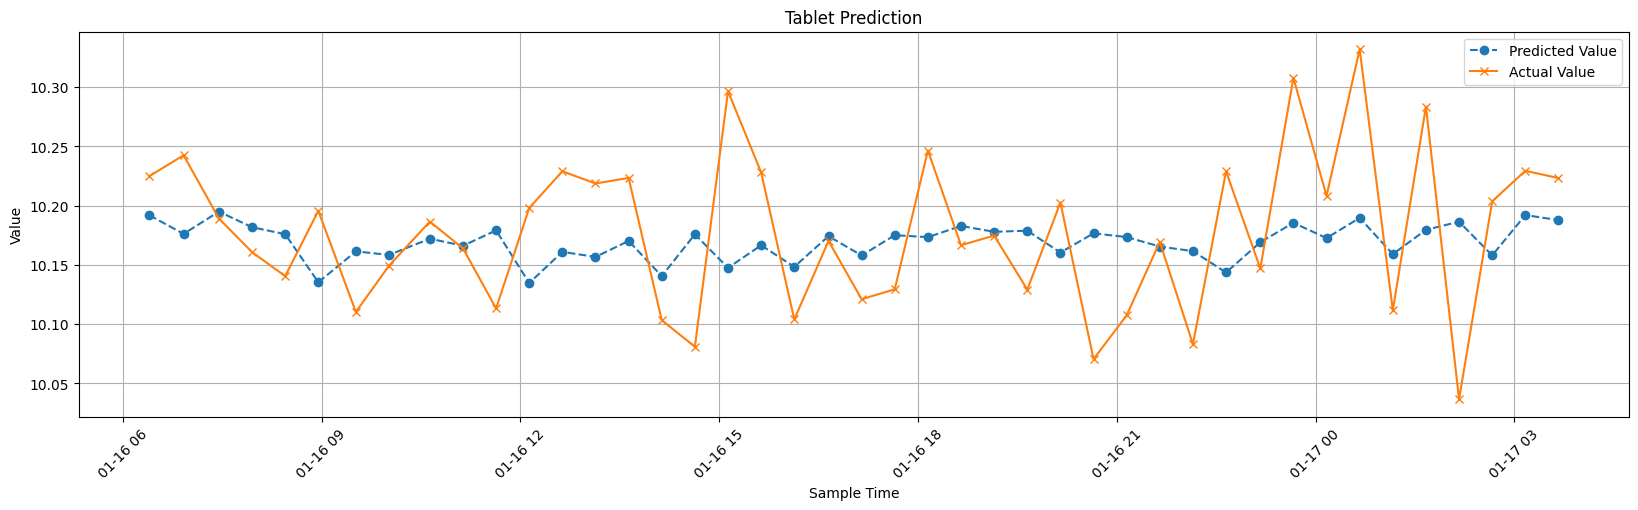

Model saved to ./model/API.pkl


In [20]:
# 直接做training
targets = ['Tablet 1', 'Tablet 2', 'Tablet 3', 'Tablet 4', 'Tablet 5', 'Tablet 6', 'Tablet 7', 'Tablet 8', 'Tablet 9', 'Tablet 10']
model = TimeSeriesRandomForestRegressor(model_name=f"API", df=result['API'], target=targets, folds=5, n_estimators=100)
model.train()

PCA reduced features to 10 dimensions


,0,1,2,3,4,5,6,7,8,9,...,Tablet 1,Tablet 2,Tablet 3,Tablet 4,Tablet 5,Tablet 6,Tablet 7,Tablet 8,Tablet 9,Tablet 10
0,-1506.649312,-754.357095,-212.323164,-593.426962,-227.140675,-374.106804,-114.773550,23.101351,-56.558601,-26.985269,...,10.21902,10.17375,9.961281,10.1037,10.31806,10.09846,10.24700,10.00731,10.03426,10.06077
1,-1506.649315,-754.357096,-212.323155,-593.426947,-227.140319,-374.106733,-114.773657,23.100542,-56.558577,-25.987900,...,10.21902,10.17375,9.961281,10.1037,10.31806,10.09846,10.24700,10.00731,10.03426,10.06077
2,-1506.649296,-754.357106,-212.323148,-593.426941,-227.141041,-374.107216,-114.770573,23.100833,-56.557053,-24.990549,...,10.21902,10.17375,9.961281,10.1037,10.31806,10.09846,10.24700,10.00731,10.03426,10.06077
3,-1506.649319,-754.357099,-212.323135,-593.426918,-227.139760,-374.106670,-114.773419,23.099080,-56.558313,-23.993165,...,10.21902,10.17375,9.961281,10.1037,10.31806,10.09846,10.24700,10.00731,10.03426,10.06077
4,-1506.649282,-754.357116,-212.323130,-593.426915,-227.141294,-374.107569,-114.767847,23.100197,-56.555525,-22.995828,...,10.21902,10.17375,9.961281,10.1037,10.31806,10.09846,10.24700,10.00731,10.03426,10.06077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418527,7671.895506,-1033.235651,-185.632704,79.608891,-289.042702,-167.156267,190.791224,18.045469,28.494564,25.717847,...,10.29079,10.26250,10.169020,10.1400,10.04942,10.09210,10.34766,10.20270,10.52143,10.15792
418528,7671.897036,-1033.250517,-185.665568,79.522220,-288.899467,-167.095222,190.374964,17.936525,28.267295,26.720254,...,10.29079,10.26250,10.169020,10.1400,10.04942,10.09210,10.34766,10.20270,10.52143,10.15792
418529,7671.889745,-1033.187756,-185.530813,79.878772,-289.331480,-167.317563,192.064869,18.267665,29.024430,27.705175,...,10.29079,10.26250,10.169020,10.1400,10.04942,10.09210,10.34766,10.20270,10.52143,10.15792
418530,7671.934507,-1033.366966,-185.892131,78.918386,-289.043230,-167.280157,191.299006,18.702150,29.060103,28.701895,...,10.29079,10.26250,10.169020,10.1400,10.04942,10.09210,10.34766,10.20270,10.52143,10.15792


/workspace/env/lib/python3.11/site-packages/cuml/internals/api_decorators.py:368: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)
Time Series Cross Validation:   0%|          | 0/5 [00:00<?, ?it/s]/workspace/env/lib/python3.11/site-packages/cuml/internals/api_decorators.py:193: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  ret = func(*args, **kwargs)
Time Series Cross Validation: 100%|██████████| 5/5 [00:04<00:00,  1.07it/s]


Time Series Cross Validation MSE Mean: 0.01237371211995467
Time Series Cross Validation R² Mean: -1.587655996517213
Final Test MSE: 0.007570378819834655
Final Test R²: -0.7387516841792636
43


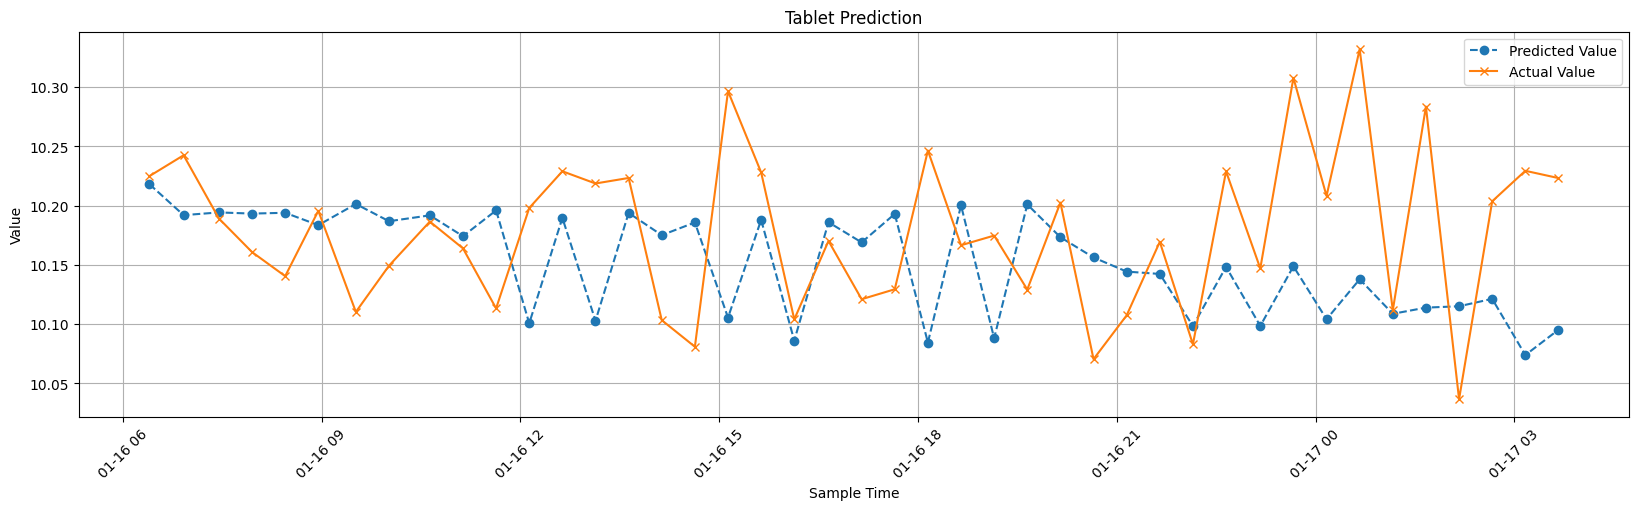

Model saved to ./model/API_PCA.pkl


In [29]:
# 先做PCA，再train model
pca = PCAProcessor(name='API_PCA', n_components=10)

X = result['API'].drop(columns=["TimeStamp", 'Batch', 'sample_id', 'sample_time'])
meta_columns = result['API'][["TimeStamp", 'Batch', 'sample_id', 'sample_time']]
y = result['API'][targets]

X_train, X_test = train_test_split(X=X, shuffle=False)

# 訓練數據，fit_transfrom
X_train_pca = pca.fit_transform(X_train.to_numpy())

# 測試數據，transfrom
X_test_pca = pca.transform(X_test.to_numpy())

# 合併pca後的數據，並轉換成X_pca_df
X_pca = np.vstack([X_train_pca, X_test_pca])
X_pca_df = pd.DataFrame(X_pca)

# 將sample_time合併進去
X_pca_df = pd.concat([X_pca_df, meta_columns, y], axis=1)

display(X_pca_df)
# 進行訓練與預測
regressor = TimeSeriesRandomForestRegressor(model_name='API_PCA', df = X_pca_df, target=targets, n_estimators=100)

regressor.train()

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit

ModuleNotFoundError: No module named 'torch'

In [ ]:
class LSTM:
    def __init__(self, df: pd.DataFrame, targets: list):
        self.df = df
        pass

    # 建立sliding_windows
    def create_sliding_windows(self, data, window_size: int, forecast: int = 1):
        X,y = [], []
        for i in range(len(data) - window_size - forecast):
            X.append(data[i:i+window_size])
            y.append()

    def train(self):
        # 先將X和y做對應
        X = self.df
    # split train, test
    # split validation set -> 將 data 分成 5 組進行訓練
    # do cross_validationa
    # do test